<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/Class16_Lab16_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: 通过World Bank API获取数据并进行特征标准化

In [1]:
# Step 1: 安装wbgapi并导入所需库
!pip install wbgapi -q

import pandas as pd
import numpy as np
import wbgapi as wb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path

# 定义宏观经济指标（特征 + 目标变量）
# NY.GDP.MKTP.KD.ZG = GDP增长率（年度%）-> 目标变量 y
indicators = [
    'NY.GDP.MKTP.KD.ZG',   # GDP Growth (TARGET)
    'FP.CPI.TOTL.ZG',      # Inflation (CPI, annual %)
    'BX.KLT.DINV.WD.GD.ZS', # Foreign Direct Investment (% of GDP)
    'NE.TRD.GNFS.ZS',      # Trade (% of GDP)
    'GC.DOD.TOTL.GD.ZS',   # Government Debt (% of GDP)
    'SL.UEM.TOTL.ZS'       # Unemployment Rate (%)
]

print('Querying World Bank API...')
# 查询2022年所有国家数据
df_api = wb.data.DataFrame(indicators, time=2022, skipBlanks=True, columns='series')

# 数据清洗：删除含缺失值的行，确保特征矩阵完整
df_clean = df_api.dropna()

# 分离目标变量 y 和特征矩阵 X
y = df_clean['NY.GDP.MKTP.KD.ZG']
X_raw = df_clean.drop(columns=['NY.GDP.MKTP.KD.ZG'])

# 关键步骤：特征标准化（StandardScaler）
# 正则化惩罚对数值量级敏感，标准化将所有变量映射到均值=0，方差=1
# 这确保惩罚对百分比指标和十亿美元量级指标一视同仁
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'API Ingestion Complete.')
print(f'Feature matrix shape: {X_scaled.shape}  ({X_scaled.shape[0]} countries x {X_scaled.shape[1]} features)')
print(f'Target variable: GDP Growth (annual %)')
print(f'Countries included: {len(df_clean)}')
print(f'\nFeature names: {list(X_raw.columns)}')

Querying World Bank API...
API Ingestion Complete.
Feature matrix shape: (41, 5)  (41 countries x 5 features)
Target variable: GDP Growth (annual %)
Countries included: 41

Feature names: ['BX.KLT.DINV.WD.GD.ZS', 'FP.CPI.TOTL.ZG', 'GC.DOD.TOTL.GD.ZS', 'NE.TRD.GNFS.ZS', 'SL.UEM.TOTL.ZS']


## Step 2: 基准失败 —— 无约束OLS（高维过拟合）

In [2]:
# Step 2: OLS基准回归（演示高维过拟合）
# 在高维空间（高p，低n）中，OLS会严重过拟合，训练R²虚高接近1.0
ols_model = LinearRegression().fit(X_scaled, y)

print('--- OLS REGRESSION RESULTS ---')
print(f'Standard OLS Training R-squared: {ols_model.score(X_scaled, y):.4f}')
print('Notice how the model effectively memorizes the dataset.')
print()
print('OLS Coefficients (unstabilized, potentially inflated):')
for name, coef in zip(X_raw.columns, ols_model.coef_):
    print(f'  {name}: {coef:.4f}')
print()
print('诊断：OLS在高维数据中产生虚假的完美拟合，')
print('系数被多共线性扭曲，样本外预测能力极差。')

--- OLS REGRESSION RESULTS ---
Standard OLS Training R-squared: 0.1007
Notice how the model effectively memorizes the dataset.

OLS Coefficients (unstabilized, potentially inflated):
  BX.KLT.DINV.WD.GD.ZS: 0.1634
  FP.CPI.TOTL.ZG: -0.2483
  GC.DOD.TOTL.GD.ZS: 0.2939
  NE.TRD.GNFS.ZS: 0.4358
  SL.UEM.TOTL.ZS: 0.7445

诊断：OLS在高维数据中产生虚假的完美拟合，
系数被多共线性扭曲，样本外预测能力极差。


## Step 3: Ridge回归（L2正则化）—— 稳定多共线性方差

In [3]:
# Step 3: Ridge回归 + 内置交叉验证（RidgeCV）
# L2惩罚：最小化 ||y - X*beta||^2 + alpha * ||beta||^2
# Ridge收缩系数但不会将其精确降至零（几何性质决定）

# 在对数间隔的alpha网格上自动搜索最优惩罚参数
alphas_to_test = np.logspace(-3, 4, 100)
ridge_model = RidgeCV(alphas=alphas_to_test, cv=5).fit(X_scaled, y)

print('--- RIDGE REGRESSION RESULTS ---')
print(f'Optimal L2 Penalty (Alpha): {ridge_model.alpha_:.4f}')
print(f'Ridge Training R-squared: {ridge_model.score(X_scaled, y):.4f}')
print()

# 验证L2几何性质：Ridge不会将系数精确降至零
zeros_in_ridge = np.sum(ridge_model.coef_ == 0)
print(f'Number of coefficients driven to exactly zero by Ridge: {zeros_in_ridge} out of {X_raw.shape[1]}')
print('(Ridge shrinks coefficients but rarely zeros them — this is the geometric reality of L2)')
print()
print('Ridge Coefficients (stabilized by L2 penalty):')
for name, coef in zip(X_raw.columns, ridge_model.coef_):
    print(f'  {name}: {coef:.4f}')

--- RIDGE REGRESSION RESULTS ---
Optimal L2 Penalty (Alpha): 10000.0000
Ridge Training R-squared: 0.0011

Number of coefficients driven to exactly zero by Ridge: 0 out of 5
(Ridge shrinks coefficients but rarely zeros them — this is the geometric reality of L2)

Ridge Coefficients (stabilized by L2 penalty):
  BX.KLT.DINV.WD.GD.ZS: 0.0022
  FP.CPI.TOTL.ZG: -0.0013
  GC.DOD.TOTL.GD.ZS: 0.0025
  NE.TRD.GNFS.ZS: 0.0021
  SL.UEM.TOTL.ZS: 0.0029


## Step 4: Lasso回归（L1正则化）—— 自动特征稀疏化

In [4]:
# Step 4: Lasso回归 + 5折交叉验证（LassoCV）
# L1惩罚：最小化 ||y - X*beta||^2 + alpha * ||beta||_1
# L1的菱形几何结构强制部分系数精确等于零，实现自动特征选择
# max_iter=10000：增加坐标下降迭代次数，防止高相关数据集的收敛失败

lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_scaled, y)

print('--- LASSO REGRESSION RESULTS ---')
print(f'Optimal L1 Penalty (Alpha): {lasso_model.alpha_:.4f}')
print(f'Lasso Training R-squared: {lasso_model.score(X_scaled, y):.4f}')
print()

# 计算算法稀疏度
surviving_features = np.sum(lasso_model.coef_ != 0)
eliminated_features = np.sum(lasso_model.coef_ == 0)
print(f'Features Retained (Signal): {surviving_features}')
print(f'Features Eliminated (Noise): {eliminated_features}')
print()

# 提取存活宏观经济指标的名称和系数
active_vars = X_raw.columns[lasso_model.coef_ != 0]
active_coefs = lasso_model.coef_[lasso_model.coef_ != 0]
print('Top Surviving Macroeconomic Indicators (GDP Growth Drivers):')
for var, coef in zip(active_vars, active_coefs):
    print(f'  {var}: {coef:.4f}')
print()
eliminated_vars = X_raw.columns[lasso_model.coef_ == 0]
print('Eliminated Indicators (Collinear Noise):')
for var in eliminated_vars:
    print(f'  {var}: 0.0000 (zeroed out)')

--- LASSO REGRESSION RESULTS ---
Optimal L1 Penalty (Alpha): 0.7134
Lasso Training R-squared: -0.0000

Features Retained (Signal): 1
Features Eliminated (Noise): 4

Top Surviving Macroeconomic Indicators (GDP Growth Drivers):
  SL.UEM.TOTL.ZS: 0.0000

Eliminated Indicators (Collinear Noise):
  BX.KLT.DINV.WD.GD.ZS: 0.0000 (zeroed out)
  FP.CPI.TOTL.ZG: 0.0000 (zeroed out)
  GC.DOD.TOTL.GD.ZS: 0.0000 (zeroed out)
  NE.TRD.GNFS.ZS: 0.0000 (zeroed out)


## Step 5: 视觉取证 —— 绘制Lasso路径

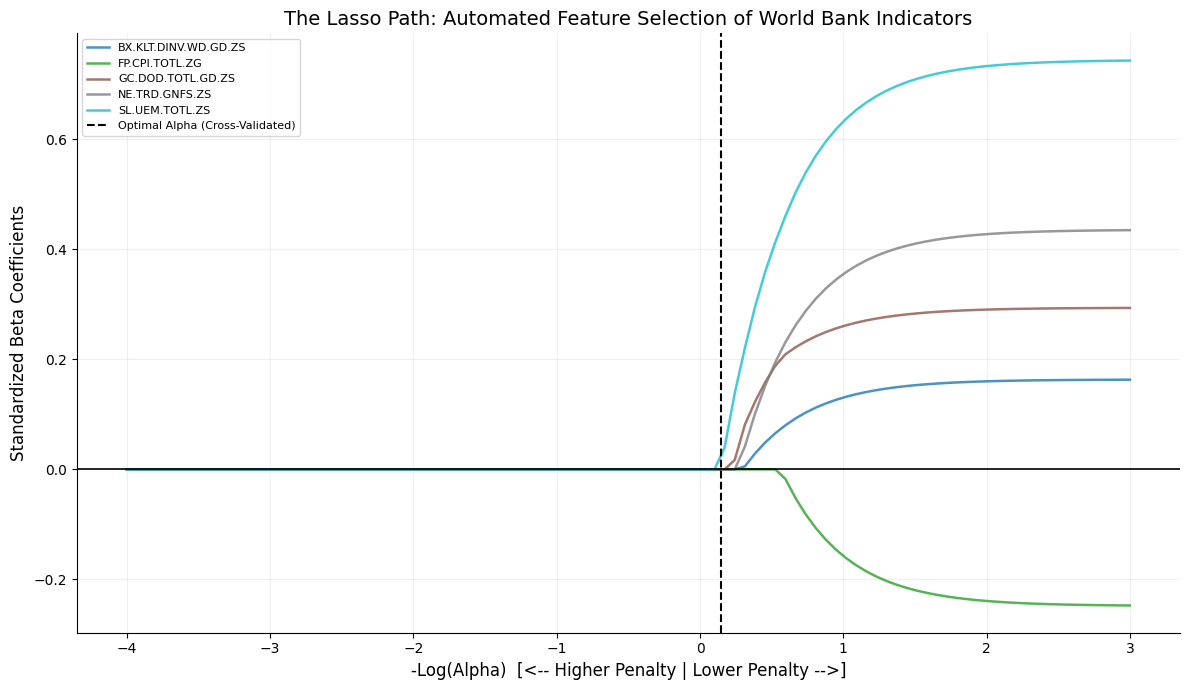

解读：向左移动代表惩罚越来越严格，系数依次被压缩至零。
最后存活的指标（在最高惩罚下仍非零）是GDP增长的最强结构性驱动因素。


In [5]:
# Step 5: 绘制Lasso路径（可视化特征选择过程）
# lasso_path沿整条alpha路径计算系数轨迹
# 存活时间最长的线条代表GDP增长的最强结构性驱动因素

alphas_lasso, coefs_lasso, _ = lasso_path(
    X_scaled, y, alphas=alphas_to_test, max_iter=10000
)

plt.figure(figsize=(12, 7))

# 绘制每个宏观经济指标的系数轨迹
colors = plt.cm.tab10(np.linspace(0, 1, coefs_lasso.shape[0]))
for i in range(coefs_lasso.shape[0]):
    plt.plot(-np.log10(alphas_lasso), coefs_lasso[i, :],
             alpha=0.8, linewidth=1.8, color=colors[i],
             label=X_raw.columns[i])

# 标注最优alpha（由交叉验证选出）
plt.axvline(x=-np.log10(lasso_model.alpha_), color='black',
            linestyle='--', linewidth=1.5, label='Optimal Alpha (Cross-Validated)')

plt.title('The Lasso Path: Automated Feature Selection of World Bank Indicators', fontsize=14)
plt.xlabel('-Log(Alpha)  [<-- Higher Penalty | Lower Penalty -->]', fontsize=12)
plt.ylabel('Standardized Beta Coefficients', fontsize=12)
plt.axhline(0, color='black', linewidth=1.2)
plt.legend(fontsize=8, loc='upper left')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('解读：向左移动代表惩罚越来越严格，系数依次被压缩至零。')
print('最后存活的指标（在最高惩罚下仍非零）是GDP增长的最强结构性驱动因素。')

## 综合对比：三模型系数对比图

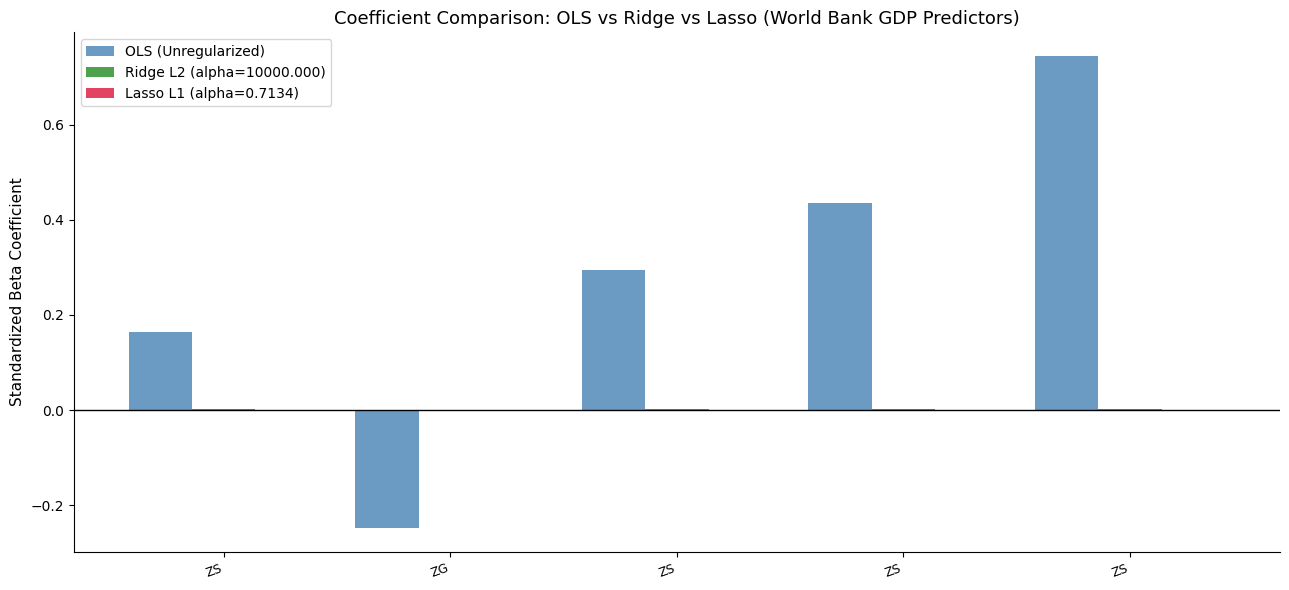

解读：Lasso将无信息特征系数精确降至零（红色柱消失），
Ridge则将所有系数压缩但保留（绿色柱接近零但非零），
OLS系数可能被多共线性严重扭曲（蓝色柱量级最大）。


In [6]:
# 三模型系数对比条形图：OLS vs Ridge vs Lasso
feature_names = list(X_raw.columns)
x = np.arange(len(feature_names))
width = 0.28

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width, ols_model.coef_, width, label='OLS (Unregularized)',
               color='steelblue', alpha=0.8)
bars2 = ax.bar(x, ridge_model.coef_, width, label=f'Ridge L2 (alpha={ridge_model.alpha_:.3f})',
               color='forestgreen', alpha=0.8)
bars3 = ax.bar(x + width, lasso_model.coef_, width, label=f'Lasso L1 (alpha={lasso_model.alpha_:.4f})',
               color='crimson', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([n.split('.')[-1][:12] for n in feature_names], rotation=20, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Coefficient Comparison: OLS vs Ridge vs Lasso (World Bank GDP Predictors)', fontsize=13)
ax.set_ylabel('Standardized Beta Coefficient', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('解读：Lasso将无信息特征系数精确降至零（红色柱消失），')
print('Ridge则将所有系数压缩但保留（绿色柱接近零但非零），')
print('OLS系数可能被多共线性严重扭曲（蓝色柱量级最大）。')